In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import urllib.request
import zipfile
import os
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.6f}".format)

print("All libraries imported successfully")
print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"statsmodels: ", end="")
import statsmodels
print(statsmodels.__version__)
print(f"yfinance:    {yf.__version__}")


All libraries imported successfully
pandas:      3.0.3
numpy:       2.4.6
statsmodels: 0.14.6
yfinance:    1.3.0


In [2]:
# ============================================
# FAMA-FRENCH 5-FACTOR DATA
# Source: Kenneth French Data Library, Dartmouth
# The authoritative source, maintained by the
# researchers themselves.
# ============================================

FF5_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/"
    "ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
)

zip_path = "../data/raw/ff5_daily.zip"

print("Downloading Fama-French 5-Factor daily data...")
print(f"Source: Kenneth French Data Library (Dartmouth)")
print(f"URL: {FF5_URL[:60]}...")

try:
    urllib.request.urlretrieve(FF5_URL, zip_path)
    file_size = os.path.getsize(zip_path) / 1024
    print(f"Download complete — {file_size:.1f} KB")
except Exception as e:
    print(f"Download failed: {e}")
    print("Try downloading manually from:")
    print("https://mba.tuck.dartmouth.edu/pages/faculty/"
          "ken.french/data_library.html")
    print("Look for: Fama/French 5 Factors (2x3) [Daily]")

Source: Kenneth French Data Library (Dartmouth)
URL: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/...
Download complete — 145.8 KB


In [3]:
# Extract zip file
print("Extracting zip file...")
with zipfile.ZipFile(zip_path, "r") as z:
    file_list = z.namelist()
    print(f"Files inside zip: {file_list}")
    z.extractall("../data/raw/")

# Find the extracted CSV
raw_dir = "../data/raw/"
all_files = os.listdir(raw_dir)
print(f"\nAll files in data/raw/: {all_files}")

# Find the FF5 CSV specifically
ff5_files = [
    f for f in all_files
    if "5_Factors" in f and
    (f.endswith(".CSV") or f.endswith(".csv"))
]

if not ff5_files:
    raise FileNotFoundError(
        "FF5 CSV not found after extraction. "
        "Check the files listed above."
    )

ff5_path = os.path.join(raw_dir, ff5_files[0])
print(f"\nFF5 file found: {ff5_files[0]}")
print(f"Full path: {ff5_path}")

# Preview first 15 lines to understand structure
print("\nFirst 15 lines of raw file:")
print("-" * 50)
with open(ff5_path, "r") as f:
    for i, line in enumerate(f):
        if i >= 15:
            break
        print(f"Line {i:2}: {line.rstrip()}")

Extracting zip file...
Files inside zip: ['F-F_Research_Data_5_Factors_2x3_daily.csv']

All files in data/raw/: ['F-F_Research_Data_5_Factors_2x3_daily.csv', 'ff5_daily.zip']

FF5 file found: F-F_Research_Data_5_Factors_2x3_daily.csv
Full path: ../data/raw/F-F_Research_Data_5_Factors_2x3_daily.csv

First 15 lines of raw file:
--------------------------------------------------
Line  0: This file was created by using the 202603 CRSP database.
Line  1: The Tbill return is the simple daily rate that, over the number of trading days
Line  2: compounds to 1-month TBill rate. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index.
Line  3: 
Line  4: ,Mkt-RF,SMB,HML,RMW,CMA,RF
Line  5: 19630701,   -0.67,    0.00,   -0.34,   -0.01,    0.16,    0.01
Line  6: 19630702,    0.79,   -0.26,    0.26,   -0.07,   -0.20,    0.01
Line  7: 19630703,    0.63,   -0.17,   -0.09,    0.18,   -0.34,    0.

In [4]:
# ============================================
# PARSE FF5 DATA
# The file has a text header before the data
# We need to skip those rows automatically
# ============================================

# Find where numeric data starts
skip_rows = 0
with open(ff5_path, "r") as f:
    for i, line in enumerate(f):
        stripped = line.strip()
        # Data rows start with an 8-digit date
        if (stripped and
                stripped[0].isdigit() and
                len(stripped.split(",")[0]) == 8):
            skip_rows = i
            break

print(f"Header rows to skip: {skip_rows}")
print(f"Data starts at line: {skip_rows}")

# Read the factor data
ff5_raw = pd.read_csv(
    ff5_path,
    skiprows=skip_rows,
    header=0
)

# Rename columns
ff5_raw.columns = (
    ["Date", "Mkt_RF", "SMB",
     "HML", "RMW", "CMA", "RF"]
    + list(ff5_raw.columns[7:])
)

# Keep only the 7 columns we need
ff5_raw = ff5_raw[
    ["Date", "Mkt_RF", "SMB",
     "HML", "RMW", "CMA", "RF"]
]

print(f"\nRaw shape: {ff5_raw.shape}")
print(f"Sample:\n{ff5_raw.head()}")

Header rows to skip: 5
Data starts at line: 5

Raw shape: (15792, 7)
Sample:
       Date    Mkt_RF       SMB       HML       RMW       CMA       RF
0  19630702  0.790000 -0.260000  0.260000 -0.070000 -0.200000 0.010000
1  19630703  0.630000 -0.170000 -0.090000  0.180000 -0.340000 0.010000
2  19630705  0.400000  0.080000 -0.270000  0.090000 -0.340000 0.010000
3  19630708 -0.630000  0.040000 -0.180000 -0.290000  0.140000 0.010000
4  19630709  0.450000  0.000000  0.090000  0.140000 -0.050000 0.010000


In [6]:
# ============================================
# CLEAN DATES AND CONVERT PERCENTAGES
# ============================================

# Convert Date column to string for filtering
ff5_raw["Date"] = ff5_raw["Date"].astype(str).str.strip()

# Keep only rows with valid 8-digit dates
# (removes footer text that some versions have)
valid_mask = (
    (ff5_raw["Date"].str.len() == 8) &
    (ff5_raw["Date"].str.isdigit())
)
ff5_clean = ff5_raw[valid_mask].copy()

# Parse dates
ff5_clean.index = pd.to_datetime(
    ff5_clean["Date"],
    format="%Y%m%d"
)
ff5_clean = ff5_clean.drop(columns=["Date"])

# Convert from percentage to decimal
# Ken French reports in percent (e.g. 0.05 = 0.05%)
# We convert to decimal (0.0005)
for col in ff5_clean.columns:
    ff5_clean[col] = pd.to_numeric(
        ff5_clean[col], errors="coerce"
    ) / 100

# Drop any remaining NaN rows
ff5_clean = ff5_clean.dropna()

# Filter to our analysis period
ff5 = ff5_clean.loc["2010-01-01":"2024-12-31"]

print("=" * 55)
print("   FAMA-FRENCH 5-FACTOR DATA — CLEAN")
print("=" * 55)
print(f"  Date range:    {ff5.index[0].date()} "
      f"to {ff5.index[-1].date()}")
print(f"  Observations:  {len(ff5):,} trading days")
print(f"  Factors:       {ff5.columns.tolist()}")
print(f"  Missing values:{ff5.isnull().sum().sum()}")
print("=" * 55)
print(f"\nSample (last 5 rows):")
print(ff5.tail())

   FAMA-FRENCH 5-FACTOR DATA — CLEAN
  Date range:    2010-01-04 to 2024-12-31
  Observations:  3,774 trading days
  Factors:       ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
  Missing values:0

Sample (last 5 rows):
              Mkt_RF       SMB       HML       RMW       CMA       RF
Date                                                                 
2024-12-24  0.011100 -0.001200 -0.000700 -0.001100 -0.003600 0.000200
2024-12-26  0.000100  0.010600 -0.001900 -0.004200  0.003500 0.000200
2024-12-27 -0.011700 -0.004400  0.005600  0.003900  0.000300 0.000200
2024-12-30 -0.010900  0.002500  0.007400  0.005400  0.001500 0.000200
2024-12-31 -0.004600  0.003200  0.007200  0.003300  0.000200 0.000200


In [7]:
# ============================================
# FACTOR DESCRIPTIVE STATISTICS
# Understand the historical factor premia
# ============================================

# Annualise the daily factor returns
factor_stats = pd.DataFrame({
    "Ann Mean (%)":
        (ff5.mean() * 252 * 100).round(4),
    "Ann Volatility (%)":
        (ff5.std() * np.sqrt(252) * 100).round(4),
    "Sharpe":
        (ff5.mean() * 252 /
         (ff5.std() * np.sqrt(252))).round(3),
    "Min (daily %)":
        (ff5.min() * 100).round(4),
    "Max (daily %)":
        (ff5.max() * 100).round(4),
    "Skewness":
        ff5.skew().round(3),
    "Kurtosis":
        ff5.kurt().round(3)
})

print("=" * 65)
print("   FACTOR DESCRIPTIVE STATISTICS (2010-2024)")
print("=" * 65)
print(factor_stats.to_string())
print("=" * 65)

print(f"\nKey insights:")
print(f"  Mkt_RF mean: {ff5['Mkt_RF'].mean()*252*100:.2f}% ann")
print(f"  — This is the equity risk premium over this period")
print(f"  SMB mean:    {ff5['SMB'].mean()*252*100:.2f}% ann")
print(f"  — Positive = small caps outperformed large caps")
print(f"  HML mean:    {ff5['HML'].mean()*252*100:.2f}% ann")
print(f"  — Negative = growth outperformed value 2010-2024")
print(f"  RMW mean:    {ff5['RMW'].mean()*252*100:.2f}% ann")
print(f"  CMA mean:    {ff5['CMA'].mean()*252*100:.2f}% ann")

   FACTOR DESCRIPTIVE STATISTICS (2010-2024)
        Ann Mean (%)  Ann Volatility (%)    Sharpe  Min (daily %)  Max (daily %)  Skewness  Kurtosis
Mkt_RF     13.418000           17.707600  0.758000     -12.010000       9.340000 -0.531000 11.093000
SMB        -0.751900           10.151500 -0.074000      -4.580000       5.710000  0.405000  4.401000
HML        -1.776800           12.394000 -0.143000      -5.030000       6.730000  0.216000  6.097000
RMW         3.032100            7.489800  0.405000      -2.230000       4.250000  0.248000  3.602000
CMA         0.166900            6.662600  0.025000      -2.920000       2.470000 -0.044000  3.508000
RF          1.133100            0.115000  9.854000       0.000000       0.020000  1.270000  0.070000

Key insights:
  Mkt_RF mean: 13.42% ann
  — This is the equity risk premium over this period
  SMB mean:    -0.75% ann
  — Positive = small caps outperformed large caps
  HML mean:    -1.78% ann
  — Negative = growth outperformed value 2010-2024
 

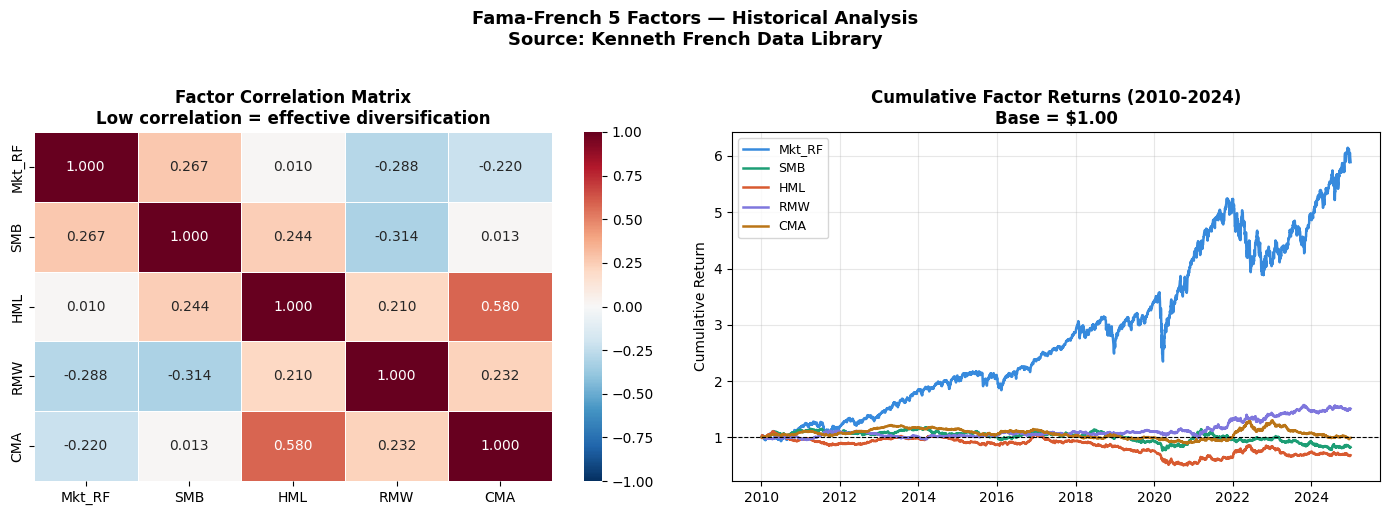

Factor analysis chart saved


In [8]:
# ============================================
# FACTOR CORRELATION MATRIX
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr = ff5[["Mkt_RF","SMB","HML","RMW","CMA"]].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title(
    "Factor Correlation Matrix\n"
    "Low correlation = effective diversification",
    fontweight="bold", fontsize=12
)

# Factor cumulative returns
cum_factors = (1 + ff5[
    ["Mkt_RF","SMB","HML","RMW","CMA"]
]).cumprod()

colors = ["#378ADD","#1D9E75","#D85A30","#7F77DD","#BA7517"]
for col, color in zip(cum_factors.columns, colors):
    axes[1].plot(
        cum_factors.index,
        cum_factors[col],
        label=col,
        color=color,
        linewidth=1.8
    )
axes[1].axhline(
    1, color="black",
    linewidth=0.8, linestyle="--"
)
axes[1].set_title(
    "Cumulative Factor Returns (2010-2024)\n"
    "Base = $1.00",
    fontweight="bold", fontsize=12
)
axes[1].set_ylabel("Cumulative Return")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Fama-French 5 Factors — Historical Analysis\n"
    "Source: Kenneth French Data Library",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/factor_analysis.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Factor analysis chart saved")

In [9]:
# ============================================
# DOWNLOAD STOCK PRICES
# Five stocks with contrasting factor profiles
# ============================================
tickers = ["AAPL", "BRK-B", "TSLA", "JNJ", "SPY"]

ticker_descriptions = {
    "AAPL":  "Apple — large-cap growth, negative HML",
    "BRK-B": "Berkshire — value investor, positive HML",
    "TSLA":  "Tesla — high beta, momentum, negative HML",
    "JNJ":   "J&J — defensive, positive RMW",
    "SPY":   "S&P 500 ETF — market benchmark (beta=1)"
}

print("Downloading stock prices from Yahoo Finance...")
print("Period: 2010-01-01 to 2024-12-31")
for t, desc in ticker_descriptions.items():
    print(f"  {t:<8} — {desc}")

prices = yf.download(
    tickers,
    start="2010-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=True
)["Close"]

# Handle single vs multi-ticker
if isinstance(prices, pd.Series):
    prices = prices.to_frame()

prices = prices.dropna(how="all")

print(f"\nDownload complete")
print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} "
      f"to {prices.index[-1].date()}")
print(f"Missing values per ticker:")
print(prices.isnull().sum())

Period: 2010-01-01 to 2024-12-31
  AAPL     — Apple — large-cap growth, negative HML
  BRK-B    — Berkshire — value investor, positive HML
  TSLA     — Tesla — high beta, momentum, negative HML
  JNJ      — J&J — defensive, positive RMW
  SPY      — S&P 500 ETF — market benchmark (beta=1)


[*********************100%***********************]  5 of 5 completed


Download complete
Shape: (3773, 5)
Date range: 2010-01-04 to 2024-12-30
Missing values per ticker:
Ticker
AAPL       0
BRK-B      0
JNJ        0
SPY        0
TSLA     122
dtype: int64


In [10]:
# ============================================
# CALCULATE RETURNS AND ALIGN WITH FF5
# ============================================

# Daily simple returns
returns = prices.pct_change().dropna()

print(f"Returns shape: {returns.shape}")

# Align dates with FF5 factors
common_dates = ff5.index.intersection(returns.index)

ff5_aligned = ff5.loc[common_dates]
ret_aligned  = returns.loc[common_dates]

print(f"\nAligned observations: {len(common_dates):,}")
print(f"Date range: {common_dates[0].date()} "
      f"to {common_dates[-1].date()}")

# ============================================
# CALCULATE EXCESS RETURNS
# Ri - Rf (risk-free rate)
# This is what goes into the regression
# ============================================
excess_returns = pd.DataFrame(index=common_dates)

for ticker in tickers:
    if ticker in ret_aligned.columns:
        excess_returns[ticker] = (
            ret_aligned[ticker] -
            ff5_aligned["RF"]
        )

print(f"\nExcess returns calculated")
print(f"Shape: {excess_returns.shape}")
print(f"Missing values: {excess_returns.isnull().sum().sum()}")

# ============================================
# PERFORMANCE SUMMARY
# ============================================
print("\n" + "=" * 60)
print("   STOCK PERFORMANCE SUMMARY (2010-2024)")
print("=" * 60)
print(f"{'Ticker':<10}{'Ann Ret':>10}"
      f"{'Ann Vol':>10}{'Sharpe':>10}"
      f"{'Max DD':>12}")
print("-" * 60)

for ticker in tickers:
    if ticker not in ret_aligned.columns:
        continue
    r   = ret_aligned[ticker].dropna()
    ann_ret = r.mean() * 252
    ann_vol = r.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol

    # Max drawdown
    cum     = (1 + r).cumprod()
    roll_max= cum.cummax()
    max_dd  = ((cum - roll_max) / roll_max).min()

    print(f"{ticker:<10}{ann_ret:>10.2%}"
          f"{ann_vol:>10.2%}{sharpe:>10.3f}"
          f"{max_dd:>12.2%}")

print("=" * 60)

Returns shape: (3650, 5)

Aligned observations: 3,650
Date range: 2010-06-30 to 2024-12-30

Excess returns calculated
Shape: (3650, 5)
Missing values: 0

   STOCK PERFORMANCE SUMMARY (2010-2024)
Ticker       Ann Ret   Ann Vol    Sharpe      Max DD
------------------------------------------------------------
AAPL          27.93%    27.73%     1.007     -43.80%
BRK-B         13.78%    19.10%     0.721     -29.57%
TSLA          54.83%    57.38%     0.956     -73.63%
JNJ           10.44%    16.80%     0.621     -27.37%
SPY           15.23%    16.93%     0.900     -33.72%


In [12]:
# ============================================
# SAVE ALL PROCESSED DATASETS
# ============================================
ff5_aligned.to_csv(
    "../data/processed/ff5_factors.csv")
excess_returns.to_csv(
    "../data/processed/excess_returns.csv")
ret_aligned.to_csv(
    "../data/processed/stock_returns.csv")
prices.loc[common_dates].to_csv(
    "../data/processed/stock_prices.csv")

# Verify files saved
print("=" * 55)
print("FILES SAVED")
print("=" * 55)
saved_files = [
    "ff5_factors.csv",
    "excess_returns.csv",
    "stock_returns.csv",
    "stock_prices.csv"
]
for f in saved_files:
    path = f"../data/processed/{f}"
    size = os.path.getsize(path) / 1024
    df   = pd.read_csv(path, index_col=0)
    print(f"  {f:<30} "
          f"{df.shape[0]:>6,} rows | "
          f"{size:>6.1f} KB")

print("=" * 55)
print(f"\n  Tickers:      {tickers}")
print(f"  Factors:      {ff5.columns.tolist()}")
print(f"  Date range:   {common_dates[0].date()} "
      f"to {common_dates[-1].date()}")
print(f"  Observations: {len(common_dates):,}")
print("=" * 55)


FILES SAVED
  ff5_factors.csv                 3,650 rows |  248.5 KB
  excess_returns.csv              3,650 rows |  425.7 KB
  stock_returns.csv               3,650 rows |  425.6 KB
  stock_prices.csv                3,650 rows |  368.2 KB

  Tickers:      ['AAPL', 'BRK-B', 'TSLA', 'JNJ', 'SPY']
  Factors:      ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
  Date range:   2010-06-30 to 2024-12-30
  Observations: 3,650
